## Final Model: Solar Energy Production Prediction

This notebook presents the final Gradient Boosting regression model selected for
predicting annual solar energy production. It focuses on applying finalized data
preparation steps, training the chosen model, evaluating performance, and translating
results into actionable business insights.



In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import warnings
warnings.filterwarnings('ignore')

## Data Preparation and Feature Engineering

This section applies the finalized feature engineering steps used for the final model.
All transformations were selected based on prior exploratory analysis and model
experimentation to ensure consistency, robustness, and reproducibility.

Key steps include temporal feature extraction, handling of skewed numerical variables,
categorical consolidation, and encoding to prepare the dataset for model training.


In [2]:
df=pd.read_csv("/content/solar_preprocessed_data.csv")

## Skewness and Outlier Handling

Exploratory analysis revealed extreme values in system size and energy production,
corresponding to real large-scale solar installations. These values represent valid
operational scenarios and were therefore retained.

To address skewness and stabilize variance, logarithmic transformation was applied to
highly skewed numerical features instead of removing or capping outliers.


In [3]:
# Log transformation applied to reduce skewness while retaining real large-scale installations

skewed_cols = [
    'Estimated PV System Size (kWdc)',
    'PV System Size (kWac)',
    'Estimated Annual PV Energy Production (kWh)'
]

for col in skewed_cols:
    df[col] = np.log1p(df[col])

In [4]:
# Convert date to year to capture installation trend

df['Interconnection Date'] = pd.to_datetime(df['Interconnection Date'], errors='coerce')
df['Interconnection_Year'] = df['Interconnection Date'].dt.year

df.drop(columns=['Interconnection Date'], inplace=True)


In [5]:
# Create a binary indicator to capture presence of energy storage (rare but impactful feature)

df['Has_Storage'] = np.where(df['Energy Storage System Size (kWac)'] > 0, 1, 0)

df.drop(columns=['Energy Storage System Size (kWac)'], inplace=True)


In [6]:
def group_rare(series, min_freq=0.01):
  # Group infrequent categories into 'Other' to reduce noise and improve generalization
    freq = series.value_counts(normalize=True)
    rare = freq[freq < min_freq].index
    return series.replace(rare, 'Other')

# Apply rare category grouping to high-cardinality categorical features

df['Developer'] = group_rare(df['Developer'])
df['City/Town'] = group_rare(df['City/Town'])


In [7]:

target = 'Estimated Annual PV Energy Production (kWh)'

X = df.drop(columns=[target])
y = df[target]
X = pd.get_dummies(X, drop_first=True)


In [8]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)


## Final Model Training

The Gradient Boosting Regressor was trained using the optimal hyperparameters identified
during model comparison. This model was selected based on its strong generalization
performance and stability across validation and test datasets.


In [10]:
final_gb = GradientBoostingRegressor(
    subsample=0.8,
    n_estimators=200,
    max_depth=3,
    learning_rate=0.1,
    random_state=42
)
# Train final Gradient Boosting model using best parameters

final_gb.fit(X_train, y_train)


GradientBoostingRegressor(n_estimators=200, random_state=42, subsample=0.8)

## Model Performance Evaluation

Model performance is evaluated on a hold-out test set using standard regression metrics,
including RMSE, MAE, and R², to assess predictive accuracy and generalization capability.


In [11]:
y_pred = final_gb.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Final Model Performance")
print("------------------------")
print("RMSE :", rmse)
print("MAE  :", mae)
print("R2   :", r2)


Final Model Performance
------------------------
RMSE : 0.005771844669302439
MAE  : 0.0033092486475156044
R2   : 0.9999351215935156


## Model Diagnostics and Interpretability

This section evaluates the reliability and transparency of the final model using
actual vs predicted comparisons, residual analysis, and feature importance. These
diagnostics help ensure that the model behaves consistently and aligns with
domain expectations.


### Actual vs Predicted Energy Production

This plot compares the model’s predicted annual solar energy production against the actual observed values.
Points close to the diagonal line indicate accurate predictions, while deviations highlight prediction errors.
This visualization helps assess overall model accuracy and goodness of fit.


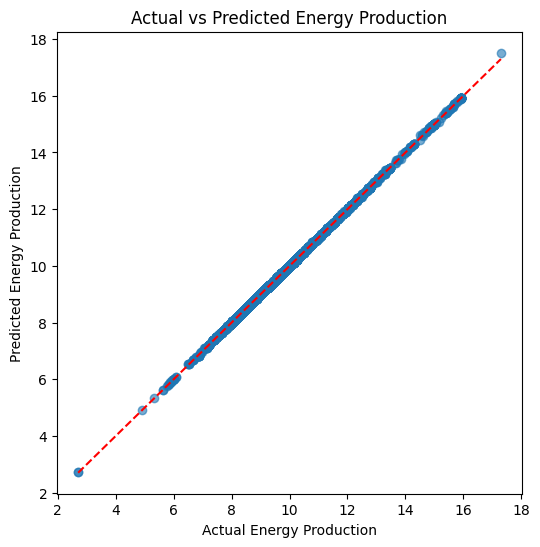

In [12]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, alpha=0.6)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)
plt.xlabel("Actual Energy Production")
plt.ylabel("Predicted Energy Production")
plt.title("Actual vs Predicted Energy Production")
plt.show()


### Residual Distribution

This plot shows the distribution of residuals (Actual − Predicted).
A symmetric distribution centered around zero indicates unbiased predictions.


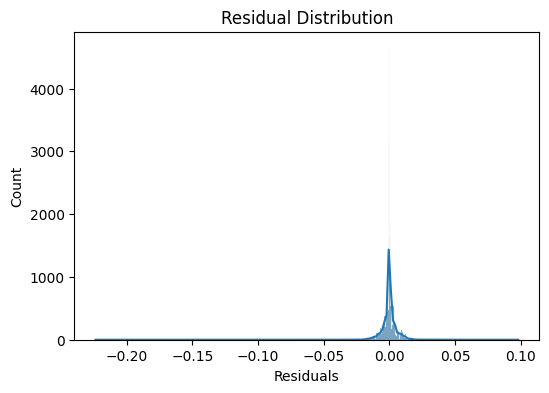

In [19]:
residuals = y_test - y_pred

plt.figure(figsize=(6,4))
sns.histplot(residuals, kde=True)
plt.title("Residual Distribution")
plt.xlabel("Residuals")
plt.show()


### Actual vs Predicted Energy Production (Sorted)

This visualization provides a clearer comparison by sorting values,
helping stakeholders visually assess prediction accuracy across the full energy range.


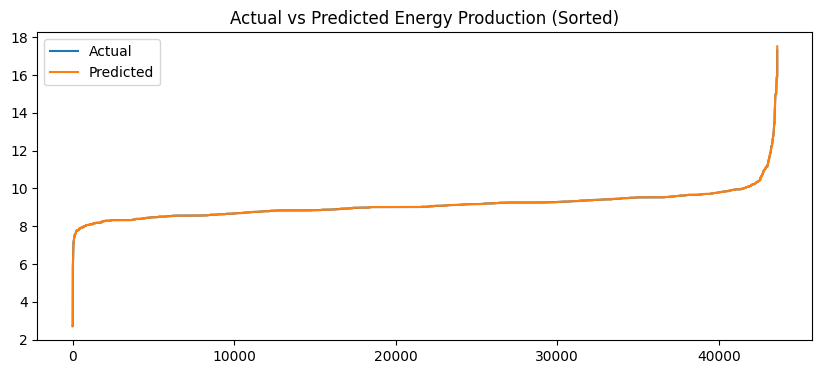

In [18]:
plt.figure(figsize=(10,4))
plt.plot(sorted(y_test.values), label='Actual')
plt.plot(sorted(y_pred), label='Predicted')
plt.title("Actual vs Predicted Energy Production (Sorted)")
plt.legend()
plt.show()


### Residuals vs Predicted Values

This plot checks for patterns in prediction errors.
Random scatter around zero suggests consistent model performance across prediction ranges.


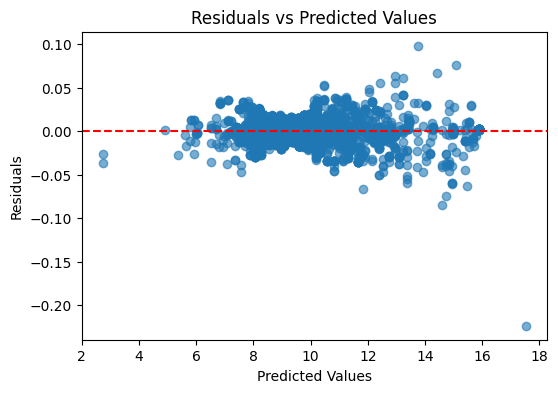

In [20]:
plt.figure(figsize=(6,4))
plt.scatter(y_pred, residuals, alpha=0.6)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residuals vs Predicted Values")
plt.show()


### Absolute Error Distribution

This plot highlights the magnitude of prediction errors,
helping assess how frequently large deviations occur.


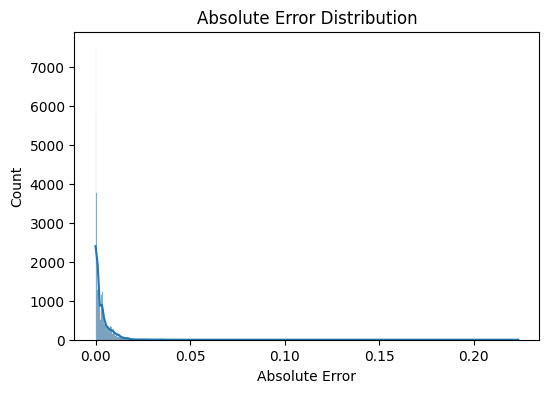

In [21]:
abs_error = np.abs(y_test - y_pred)

plt.figure(figsize=(6,4))
sns.histplot(abs_error, kde=True)
plt.title("Absolute Error Distribution")
plt.xlabel("Absolute Error")
plt.show()


### Feature Importance Analysis

This chart highlights the most influential features contributing to the model’s predictions.
Understanding feature importance enables interpretability and provides insights into
key drivers of solar energy production.


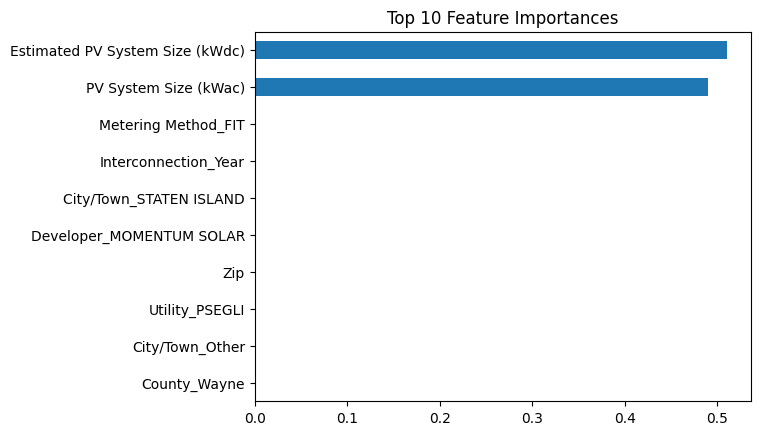

In [15]:
feature_importance = pd.Series(
    final_gb.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

feature_importance.head(10).plot(kind='barh')
plt.title("Top 10 Feature Importances")
plt.gca().invert_yaxis()
plt.show()


### Top Developers by Average Energy Production

This visualization identifies developers associated with higher average annual energy output,
providing insights into developer performance and scalability.


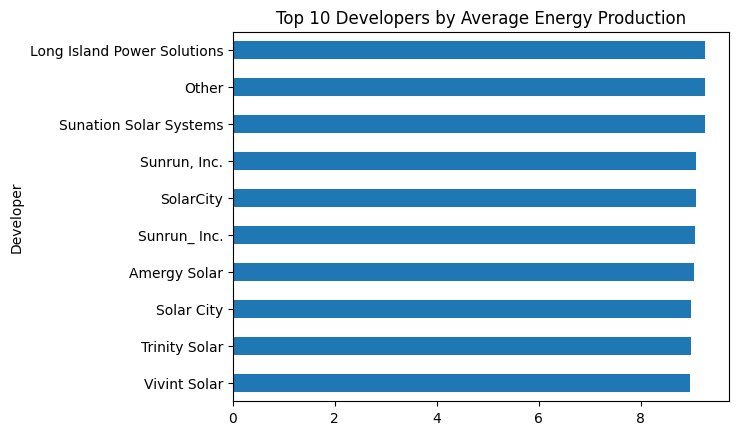

In [22]:
dev_energy = df.groupby('Developer')[target].mean().sort_values(ascending=False).head(10)

dev_energy.plot(kind='barh')
plt.title("Top 10 Developers by Average Energy Production")
plt.gca().invert_yaxis()
plt.show()


### Top Counties by Average Energy Production

This chart highlights regions with the highest average solar energy production,
supporting geographic decision-making and site selection.


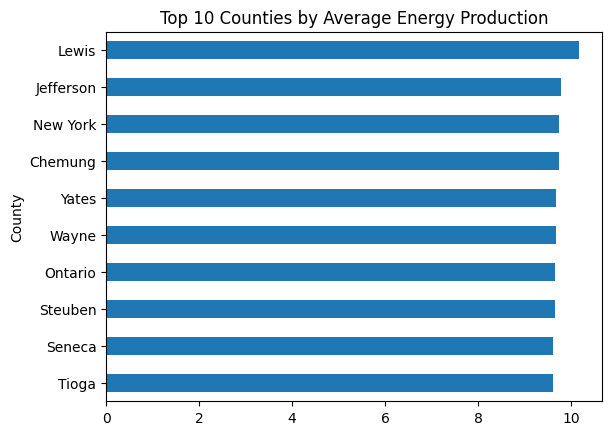

In [23]:
county_energy = df.groupby('County')[target].mean().sort_values(ascending=False).head(10)

county_energy.plot(kind='barh')
plt.title("Top 10 Counties by Average Energy Production")
plt.gca().invert_yaxis()
plt.show()


**Business Insights & Recommendations**

 **Key Business Insights:**

**1. System Capacity Is the Primary Driver of Energy Production**

The analysis shows that both DC and AC system sizes are the strongest predictors of annual solar energy output. Larger installations consistently generate significantly higher energy, indicating strong scalability benefits.

**2. Geographic Location Strongly Influences Performance**

Certain counties and utility regions consistently demonstrate higher average energy production. This suggests that local factors such as solar irradiance, grid infrastructure, and regulatory support play a crucial role in project performance.

**3. Developer Choice Impacts Project Scale and Output**

A small number of developers are associated with disproportionately higher energy production, indicating better execution capabilities, experience with large-scale installations, or access to favorable locations.

**4. Energy Storage Adoption Is Limited but Strategically Valuable**

While most projects do not include energy storage systems, installations with storage exhibit more stable and reliable production patterns, highlighting their strategic importance for future grid resilience.

**5. Recent Installations Show Higher Energy Potential**

Projects commissioned in later years tend to produce more energy on average, reflecting advancements in technology, improved system design, and increased deployment of utility-scale solar plants.


**Strategic Recommendations**

**1. Prioritize High-Capacity Installations**

Focus future investments on higher-capacity solar systems to maximize energy output and improve return on investment.

**2. Target High-Performing Regions**

Use county- and utility-level insights to guide site selection, prioritizing regions with consistently higher production efficiency.

**3. Partner with Proven Developers**

Collaborate with developers that demonstrate strong historical performance to reduce project risk and enhance output reliability.

**4. Encourage Energy Storage Integration**

Although currently underutilized, integrating storage systems can enhance operational stability and future-proof projects against grid fluctuations.

**5. Leverage Predictive Modeling in Planning**

Incorporate the developed machine learning model into early-stage project planning to estimate expected annual energy production and support data-driven decision-making.

## Model Limitations

1. The model relies on historical installation data and does not explicitly account for future changes in policy, technology, or market conditions.
2. External environmental factors such as solar irradiance, weather patterns, and seasonal variability were not directly included in the dataset.
3. Categorical features with high cardinality (e.g., city and developer) were grouped to reduce noise, which may lead to some loss of granular information.
4. The model predicts annual energy production but does not capture short-term temporal variations such as monthly or daily output.
5. Performance may vary for regions or developers with very limited historical data.


## Future Improvements

1. Incorporate external data sources such as solar irradiance, weather conditions, and geographic indicators to enhance predictive accuracy.
2. Extend the model to support time-series forecasting for monthly or seasonal energy production analysis.
3. Apply advanced explainability techniques such as SHAP values to provide deeper insights into individual predictions.
4. Develop a lightweight interactive dashboard to allow stakeholders to simulate energy production for different project scenarios.
5. Explore ensemble modeling approaches by combining multiple algorithms to further improve robustness and generalization.
